# Notebook 3: Neural Networks & Real-World Imaging with eht-imaging

---

So far, our "model" has been either polynomial coefficients (Notebook 1) or raw pixel values (Notebook 2). But what if the model itself could be more expressive?


In this notebook we will:

1. Build a neural network from scratch in JAX and fit the same noisy sine data from Notebook 1.
2. Use a neural network as an *implicit image representation* to reconstruct our ring from sparse Fourier data.
3. Use `eht-imaging`, the library built by the EHT collaboration, to reconstruct the **actual M87\* black hole** from real VLBI data.

---

# What Is a Neural Network?

---

A neural network is a **parameterized function** composed of linear transformations and nonlinearities:

$$\mathbf{h} = \sigma(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1), \quad y = \mathbf{W}_2 \mathbf{h} + \mathbf{b}_2$$

where $\sigma$ is an **activation function** (e.g., $\tanh$) applied element-wise.

```
         INPUT          HIDDEN LAYER          OUTPUT
         ─────          ────────────          ──────

                         ┌─────┐
                    ┌───►│ h_1 │───┐
                    │    └─────┘   │
                    │    ┌─────┐   │
          ┌─────┐   ├───►│ h_2 │───┤    ┌─────┐
          │  x  │───┤    └─────┘   ├───►│  y  │
          └─────┘   │    ┌─────┐   │    └─────┘
                    ├───►│ h_3 │───┤
                    │    └─────┘   │
                    │    ┌─────┐   │
                    └───►│ h_4 │───┘
                         └─────┘

          W_1, b_1 ──────►  σ  ──────► W_2, b_2
```

Each arrow carries a **weight** (a number to be learned). The activation $\sigma$ introduces **nonlinearity** — without it, stacking linear layers would just give another linear function.

**This is just a Python function.** And `jax.grad` works on it!

## Build a Neural Network in JAX

We store all learnable parameters in a dictionary. This lets us use `jax.tree.map` to apply gradient updates to every parameter at once. the same pattern we used for pixel arrays in Notebook 2, now applied to weight matrices.

In [27]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=300
plt.rcParams["xtick.direction"]="out"
plt.rcParams["ytick.direction"]="out"
plt.rcParams['font.family'] = 'sans-serif'
%matplotlib inline

def init_params(key, n_in, n_hidden, n_out):
    """Initialize neural network parameters randomly."""
    k1, k2 = jax.random.split(key)
    params = {
        'W1': 0.1 * jax.random.normal(k1, (n_in, n_hidden)),
        'b1': jnp.zeros(n_hidden),
        'W2': 0.1 * jax.random.normal(k2, (n_hidden, n_out)),
        'b2': jnp.zeros(n_out),
    }
    return params

def neural_net(params, x):
    """A simple 2-layer neural network."""
    h = jnp.tanh(x @ params['W1'] + params['b1'])  # hidden layer + activation
    return h @ params['W2'] + params['b2']            # output layer

# Quick test
key = jax.random.PRNGKey(0)
test_params = init_params(key, n_in=1, n_hidden=4, n_out=1)
test_x = jnp.array([[0.5]])
print(f"Input shape:  {test_x.shape}")
print(f"Output shape: {neural_net(test_params, test_x).shape}")
print(f"Output value: {neural_net(test_params, test_x)}")
print(f"\nParameters:")
for name, val in test_params.items():
    print(f"  {name}: shape {val.shape}")

Input shape:  (1, 1)
Output shape: (1, 1)
Output value: [[-0.00173249]]

Parameters:
  W1: shape (1, 4)
  b1: shape (4,)
  W2: shape (4, 1)
  b2: shape (1,)


## Demo: Fit the Sine Data from Notebook 1

Let's reuse the exact same noisy sine data from Notebook 1. In that notebook we fit a polynomial; now we fit a neural network. The training recipe is identical:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}\left(\text{NN}(x_i;\,\theta) - y_i\right)^2$$

$$\theta \leftarrow \theta - \eta\,\nabla_\theta \mathcal{L}$$

In [36]:
# Same noisy sine data from Notebook 1
np.random.seed(42)
x_data = np.linspace(0, 2*np.pi, 30)
y_data = np.sin(x_data) + 0.3 * np.random.randn(30)

# Reshape for the NN: each input is a 1D vector
x_jax = jnp.array(x_data).reshape(-1, 1)
y_jax = jnp.array(y_data).reshape(-1, 1)

In [ ]:
def nn_loss(params, x, y):
    """Mean squared error for the neural network."""
    pred = neural_net(params, x)
    return jnp.mean((pred - y)**2)

# 32 hidden units = 97 parameters for 30 data points
key = jax.random.PRNGKey(0)
params = init_params(key, n_in=1, n_hidden=32, n_out=1)

# Adam optimizer with lr=0.005 (lr=0.01 causes loss spikes)
grad_fn = jax.jit(jax.grad(nn_loss))
lr = 0.005
m_s = jax.tree.map(jnp.zeros_like, params)
v_s = jax.tree.map(jnp.zeros_like, params)
losses = []

for step in range(1, 5001):
    loss_val = nn_loss(params, x_jax, y_jax)
    grads = grad_fn(params, x_jax, y_jax)
    m_s = jax.tree.map(lambda mi, gi: 0.9*mi + 0.1*gi, m_s, grads)
    v_s = jax.tree.map(lambda vi, gi: 0.999*vi + 0.001*gi**2, v_s, grads)
    m_hat = jax.tree.map(lambda mi: mi/(1-0.9**step), m_s)
    v_hat = jax.tree.map(lambda vi: vi/(1-0.999**step), v_s)
    params = jax.tree.map(lambda p, mh, vh: p - lr*mh/(jnp.sqrt(vh)+1e-8),
                           params, m_hat, v_hat)
    losses.append(float(loss_val))

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss:   {losses[-1]:.6f}")
print(f"\nTotal parameters: {sum(p.size for p in jax.tree.leaves(params))}")

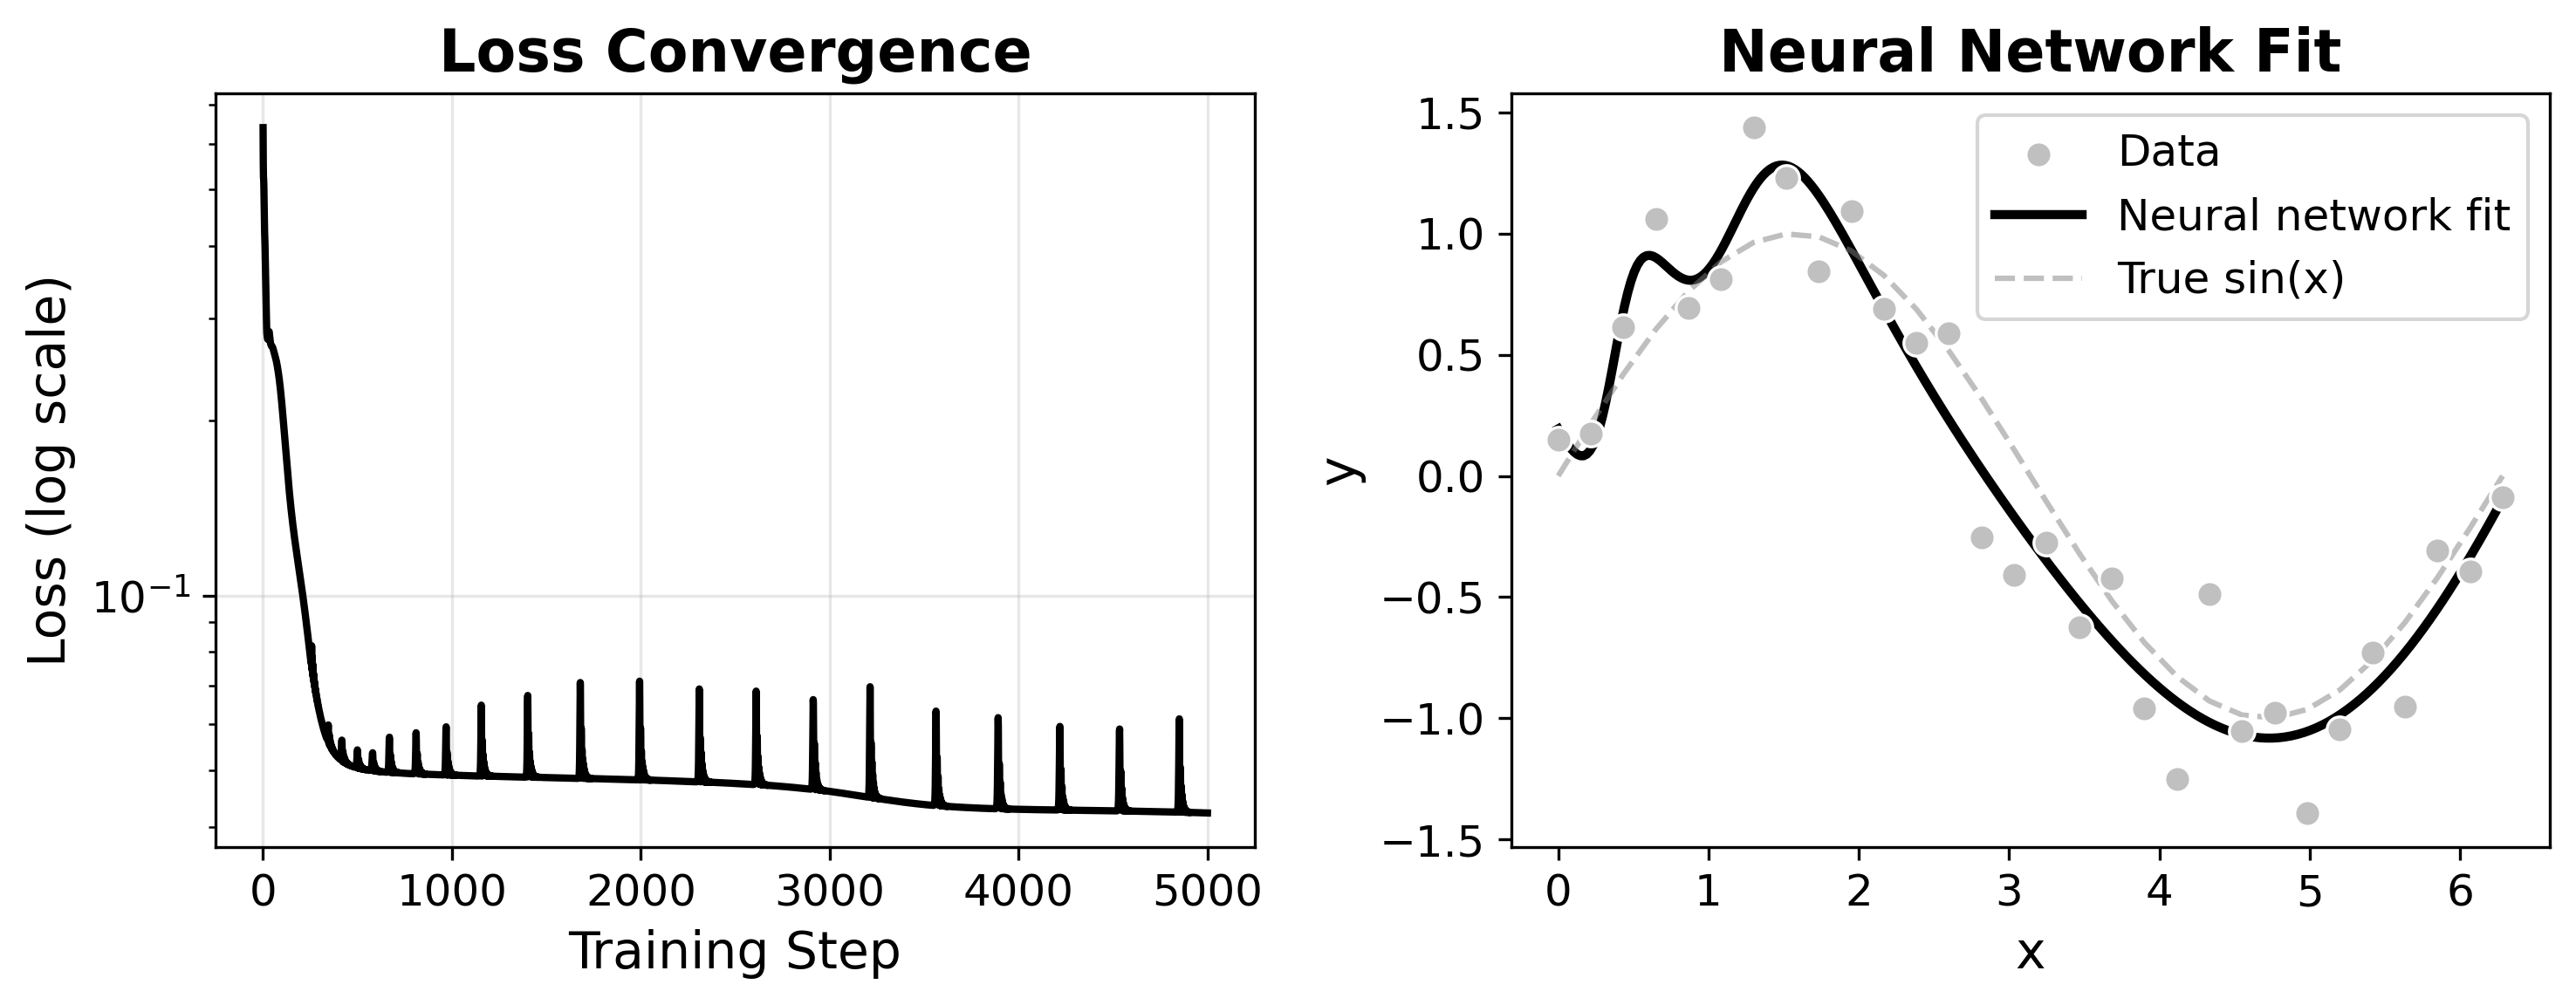

Same recipe as before: Model + Loss + jax.grad + Update.
But now the model is a neural network.


In [38]:
# Visualize: loss convergence + NN fit
x_smooth = jnp.linspace(0, 2*np.pi, 300).reshape(-1, 1)
y_pred = neural_net(params, x_smooth)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Loss curve
axes[0].semilogy(losses, color='k', lw=2)
axes[0].set_xlabel('Training Step', fontsize=14)
axes[0].set_ylabel('Loss (log scale)', fontsize=14)
axes[0].set_title('Loss Convergence', fontsize=16, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Fit
axes[1].scatter(x_data, y_data, color='silver', s=50, edgecolors='white',
                linewidth=0.8, zorder=5, label='Data')
axes[1].plot(np.array(x_smooth).ravel(), np.array(y_pred).ravel(),
             color='k', lw=2.5, label='Neural network fit')
axes[1].plot(x_data, np.sin(x_data), color='gray', lw=1.5, ls='--',
             alpha=0.5, label='True sin(x)')
axes[1].set_xlabel('x', fontsize=14)
axes[1].set_ylabel('y', fontsize=14)
axes[1].set_title('Neural Network Fit', fontsize=16, fontweight='bold')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

print("Same recipe as before: Model + Loss + jax.grad + Update.")
print("But now the model is a neural network.")

### Pause and compare.

In Notebook 1, the degree-3 polynomial struggled to match the sine wave. The neural network with 32 hidden units fits it almost perfectly.

Why? A polynomial of degree $k$ has $k+1$ parameters and can only represent functions with at most $k$ turning points. A neural network with $\tanh$ activations can approximate **any continuous function** (the Universal Approximation Theorem). More capacity = better fit.

But the training recipe is **identical**: `jax.grad` + gradient descent.

---

### Try This!

Change the hidden layer size from 32 to **4**. What happens? Now try **128**. What is the effect of network capacity?

In [ ]:
# === TRY THIS: Change n_hidden and re-run! ===

def train_nn(n_hidden=32, n_steps=5000, lr=0.005):
    """Train a neural network with a given hidden layer size using Adam."""
    key = jax.random.PRNGKey(0)
    params = init_params(key, n_in=1, n_hidden=n_hidden, n_out=1)
    grad_fn = jax.jit(jax.grad(nn_loss))
    m = jax.tree.map(jnp.zeros_like, params)
    v = jax.tree.map(jnp.zeros_like, params)
    losses = []
    for step in range(1, n_steps + 1):
        loss_val = nn_loss(params, x_jax, y_jax)
        grads = grad_fn(params, x_jax, y_jax)
        m = jax.tree.map(lambda mi, gi: 0.9*mi + 0.1*gi, m, grads)
        v = jax.tree.map(lambda vi, gi: 0.999*vi + 0.001*gi**2, v, grads)
        m_hat = jax.tree.map(lambda mi: mi/(1-0.9**step), m)
        v_hat = jax.tree.map(lambda vi: vi/(1-0.999**step), v)
        params = jax.tree.map(lambda p, mh, vh: p - lr*mh/(jnp.sqrt(vh)+1e-8), params, m_hat, v_hat)
        losses.append(float(loss_val))
    return params, losses

hidden_sizes = [4, 32, 128]
x_smooth = jnp.linspace(0, 2*np.pi, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(14, 4))

for idx, nh in enumerate(hidden_sizes):
    p, l = train_nn(n_hidden=nh)
    y_pred = neural_net(p, x_smooth)
    n_params = sum(v.size for v in jax.tree.leaves(p))

    axes[idx].scatter(x_data, y_data, color='silver', s=40, edgecolors='white',
                      linewidth=0.5, zorder=5)
    axes[idx].plot(np.array(x_smooth).ravel(), np.array(y_pred).ravel(),
                   color='k', lw=2.5)
    axes[idx].plot(x_data, np.sin(x_data), color='gray', lw=1, ls='--', alpha=0.5)
    axes[idx].set_title(f'n_hidden = {nh}\n({n_params} params, loss = {l[-1]:.4f})',
                        fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('x', fontsize=12)
    axes[idx].set_ylim(-2, 2)

plt.suptitle('Effect of Network Capacity', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

#  Neural Networks for Imaging | Implicit Representations

---

## The Idea

In Notebook 2, our "model" was a flat array of pixel values — one free parameter per pixel. This is flexible but has no built-in structure. To avoid noisy reconstructions, we had to add explicit regularization (Total Variation).

What if instead we represent the image as a **neural network**?

$$I(x, y) = \text{NN}(x, y;\, \theta)$$

The network takes a coordinate $(x, y)$ as input and outputs the **brightness** at that point. We optimize the network weights $\theta$ instead of pixel values.

This is called an **implicit neural representation** (INR) or **coordinate network**. The image is never stored as a pixel grid — it exists only as the function the network computes.

**Why is this useful?** The network's architecture acts as a **built-in regularizer**. A small network can only represent smooth functions — it naturally avoids the pixel-level noise that plagued our unregularized reconstructions in Notebook 2.

## Implementation

We reuse the exact same `neural_net` and `init_params` from Section 1. The only new piece is a function that evaluates the network on a grid of $(x, y)$ coordinates to produce an image.

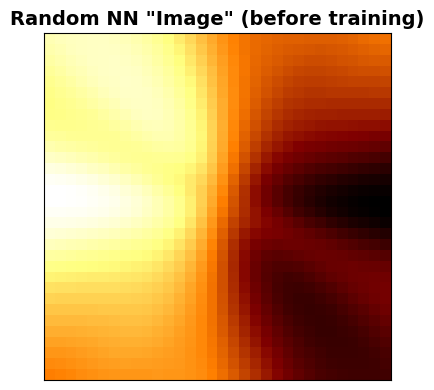

3-layer NN with 128 hidden units: 17025 parameters
Image has 1024 pixels — the NN is a compressed representation.
Note how the output is already smooth, unlike random pixel noise!


In [6]:
IMG_N = 32  # 32x32 image (same as Notebook 2)

def init_deep_params(key, n_in, n_hidden, n_out):
    """Initialize a 3-layer neural network."""
    k1, k2, k3 = jax.random.split(key, 3)
    return {
        'W1': 0.5 * jax.random.normal(k1, (n_in, n_hidden)),
        'b1': jnp.zeros(n_hidden),
        'W2': 0.5 * jax.random.normal(k2, (n_hidden, n_hidden)),
        'b2': jnp.zeros(n_hidden),
        'W3': 0.5 * jax.random.normal(k3, (n_hidden, n_out)),
        'b3': jnp.zeros(n_out),
    }

def deep_net(params, x):
    """A 3-layer neural network — deeper = more expressive."""
    h1 = jnp.tanh(x @ params['W1'] + params['b1'])
    h2 = jnp.tanh(h1 @ params['W2'] + params['b2'])
    return h2 @ params['W3'] + params['b3']

def image_from_nn(params, N):
    """Generate an image from a neural network."""
    coords = jnp.arange(N) - N // 2
    xx, yy = jnp.meshgrid(coords, coords)
    xy = jnp.stack([xx.ravel() / (N / 2), yy.ravel() / (N / 2)], axis=-1)
    return deep_net(params, xy).ravel()

# Quick test
key = jax.random.PRNGKey(42)
test_params = init_deep_params(key, n_in=2, n_hidden=128, n_out=1)
test_img = image_from_nn(test_params, IMG_N)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(np.array(test_img.reshape(IMG_N, IMG_N)), cmap='afmhot', origin='lower')
ax.set_title('Random NN "Image" (before training)', fontsize=14, fontweight='bold')
ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

n_params = sum(p.size for p in jax.tree.leaves(test_params))
print(f"3-layer NN with 128 hidden units: {n_params} parameters")
print(f"Image has {IMG_N*IMG_N} pixels — the NN is a compressed representation.")
print("Note how the output is already smooth, unlike random pixel noise!")

## Fitting an Image with a Neural Network

Instead of storing the image as a grid of pixel values, the NN takes a coordinate $(x, y)$ and outputs the brightness. We train it by showing it the true pixel values at each coordinate — the NN learns to represent the image as a smooth function.

$$\mathcal{L}(\theta) = \sum_{x,y} \left( \text{NN}(x, y;\, \theta) - I_{\text{true}}(x,y) \right)^2$$

The key insight: with **fewer parameters** than pixels, the NN can only represent smooth images. This acts as a **built-in regularizer** — no TV needed!

In [7]:
IMG_N = 32

# Ground truth ring (max-normalized)
y32, x32 = np.mgrid[-IMG_N//2:IMG_N//2, -IMG_N//2:IMG_N//2]
r32 = np.sqrt(x32**2 + y32**2).astype(float)
ring32 = np.exp(-((r32 - 8)**2) / (2 * 2.0**2))
ring32 = ring32 / ring32.max()

# Prepare coordinate-value pairs for training
coords = jnp.arange(IMG_N) - IMG_N // 2
xx, yy = jnp.meshgrid(coords, coords)
xy_train = jnp.stack([xx.ravel() / (IMG_N / 2), yy.ravel() / (IMG_N / 2)], axis=-1)  # normalized to [-1, 1]
target = jnp.array(ring32.ravel(), dtype=jnp.float32)

print(f"Training data: {len(target)} coordinate-value pairs")
print(f"Pixel value range: [{float(target.min()):.3f}, {float(target.max()):.3f}]")

Training data: 1024 coordinate-value pairs
Pixel value range: [0.000, 1.000]


In [8]:
# Train the NN to represent the ring image using Adam optimizer

def nn_image_loss(params):
    pred = deep_net(params, xy_train).ravel()
    return jnp.mean((pred - target)**2)

nn_grad_fn = jax.jit(jax.grad(nn_image_loss))

key = jax.random.PRNGKey(0)
nn_params = init_deep_params(key, n_in=2, n_hidden=128, n_out=1)
lr = 0.01

# Adam optimizer for stable convergence
m_nn = jax.tree.map(jnp.zeros_like, nn_params)
v_nn = jax.tree.map(jnp.zeros_like, nn_params)

nn_losses = []
nn_snapshots = {}
nn_snapshot_steps = [0, 500, 2000, 5000, 10000]

for step in range(1, 10001):
    if step == 1:
        nn_snapshots[0] = np.array(deep_net(nn_params, xy_train).ravel().reshape(IMG_N, IMG_N))
    if step in nn_snapshot_steps:
        nn_snapshots[step] = np.array(deep_net(nn_params, xy_train).ravel().reshape(IMG_N, IMG_N))
    
    loss_val = float(nn_image_loss(nn_params))
    grads = nn_grad_fn(nn_params)
    
    # Adam update
    m_nn = jax.tree.map(lambda mi, gi: 0.9*mi + 0.1*gi, m_nn, grads)
    v_nn = jax.tree.map(lambda vi, gi: 0.999*vi + 0.001*gi**2, v_nn, grads)
    m_hat = jax.tree.map(lambda mi: mi/(1-0.9**step), m_nn)
    v_hat = jax.tree.map(lambda vi: vi/(1-0.999**step), v_nn)
    nn_params = jax.tree.map(lambda p, mh, vh: p - lr*mh/(jnp.sqrt(vh)+1e-8),
                              nn_params, m_hat, v_hat)
    nn_losses.append(loss_val)

n_params = sum(p.size for p in jax.tree.leaves(nn_params))
print(f"Initial loss: {nn_losses[0]:.4f}")
print(f"Final loss:   {nn_losses[-1]:.6f}")
print(f"\nNN parameters: {n_params}")
print(f"Image pixels:  {IMG_N*IMG_N}")

Initial loss: 25.2361
Final loss:   0.000174

NN parameters: 17025
Image pixels:  1024


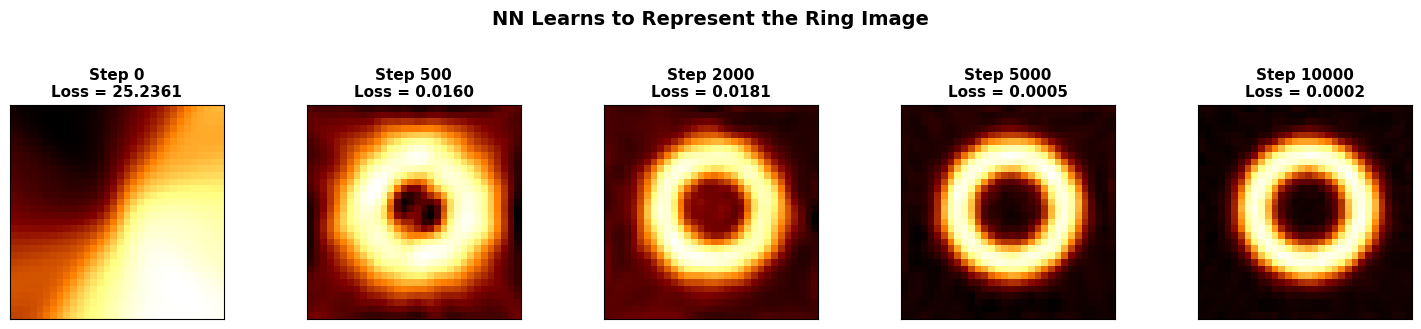

The NN learns to represent the ring as a continuous function I(x,y) = NN(x,y).


In [9]:
# Watch the NN learn to represent the ring
fig, axes = plt.subplots(1, len(nn_snapshot_steps), figsize=(15, 3))

for idx, step in enumerate(nn_snapshot_steps):
    axes[idx].imshow(nn_snapshots[step], cmap='afmhot', origin='lower')
    axes[idx].set_title(f'Step {step}\nLoss = {nn_losses[min(step, len(nn_losses)-1)]:.4f}',
                        fontsize=11, fontweight='bold')
    axes[idx].set_xticks([]); axes[idx].set_yticks([])

plt.suptitle('NN Learns to Represent the Ring Image', fontsize=14, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()

print("The NN learns to represent the ring as a continuous function I(x,y) = NN(x,y).")

---

# Real-World Imaging with eht-imaging

We have been working with simulated rings and random Fourier samples. Now we will load the **actual VLBI data** from the Event Horizon Telescope's 2017 observations of M87* and reconstruct the **real black hole image** using `eht-imaging`.

## Step 3.1: Loading Real EHT Data

The file `SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits` contains real observations of M87* from **April 6, 2017** (MJD 57849). one of the four observing nights that produced the historic first image. This data was publicly released by the EHT collaboration.

In [62]:
import warnings
warnings.filterwarnings('ignore')
import ehtim as eh

# Load the REAL M87* observation from April 2017!
obs = eh.obsdata.load_uvfits('./data/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits')

print(f"Source: {obs.source}")
print(f"Number of visibilities: {len(obs.data)}")
print(f"Observing frequency: {obs.rf/1e9:.1f} GHz")
print(f"Bandwidth: {obs.bw/1e9:.1f} GHz")
print(f"Resolution: {obs.res()*206265e6:.1f} microarcseconds")
print(f"\nTelescopes: {obs.tarr['site']}")

Loading uvfits:  ./data/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Source: M87
Number of visibilities: 8645
Observing frequency: 227.1 GHz
Bandwidth: 1.9 GHz
Resolution: 25.0 microarcseconds

Telescopes: ['AA' 'AP' 'AZ' 'JC' 'LM' 'PV' 'SM' 'SR']


## Step 3.2: Exploring the Data

Before reconstructing an image, let's look at the raw data. Remember from Notebook 2: each pair of telescopes measures one complex Fourier component (a **visibility**). The set of all measured $(u,v)$ points is the **$u$-$v$ coverage**.

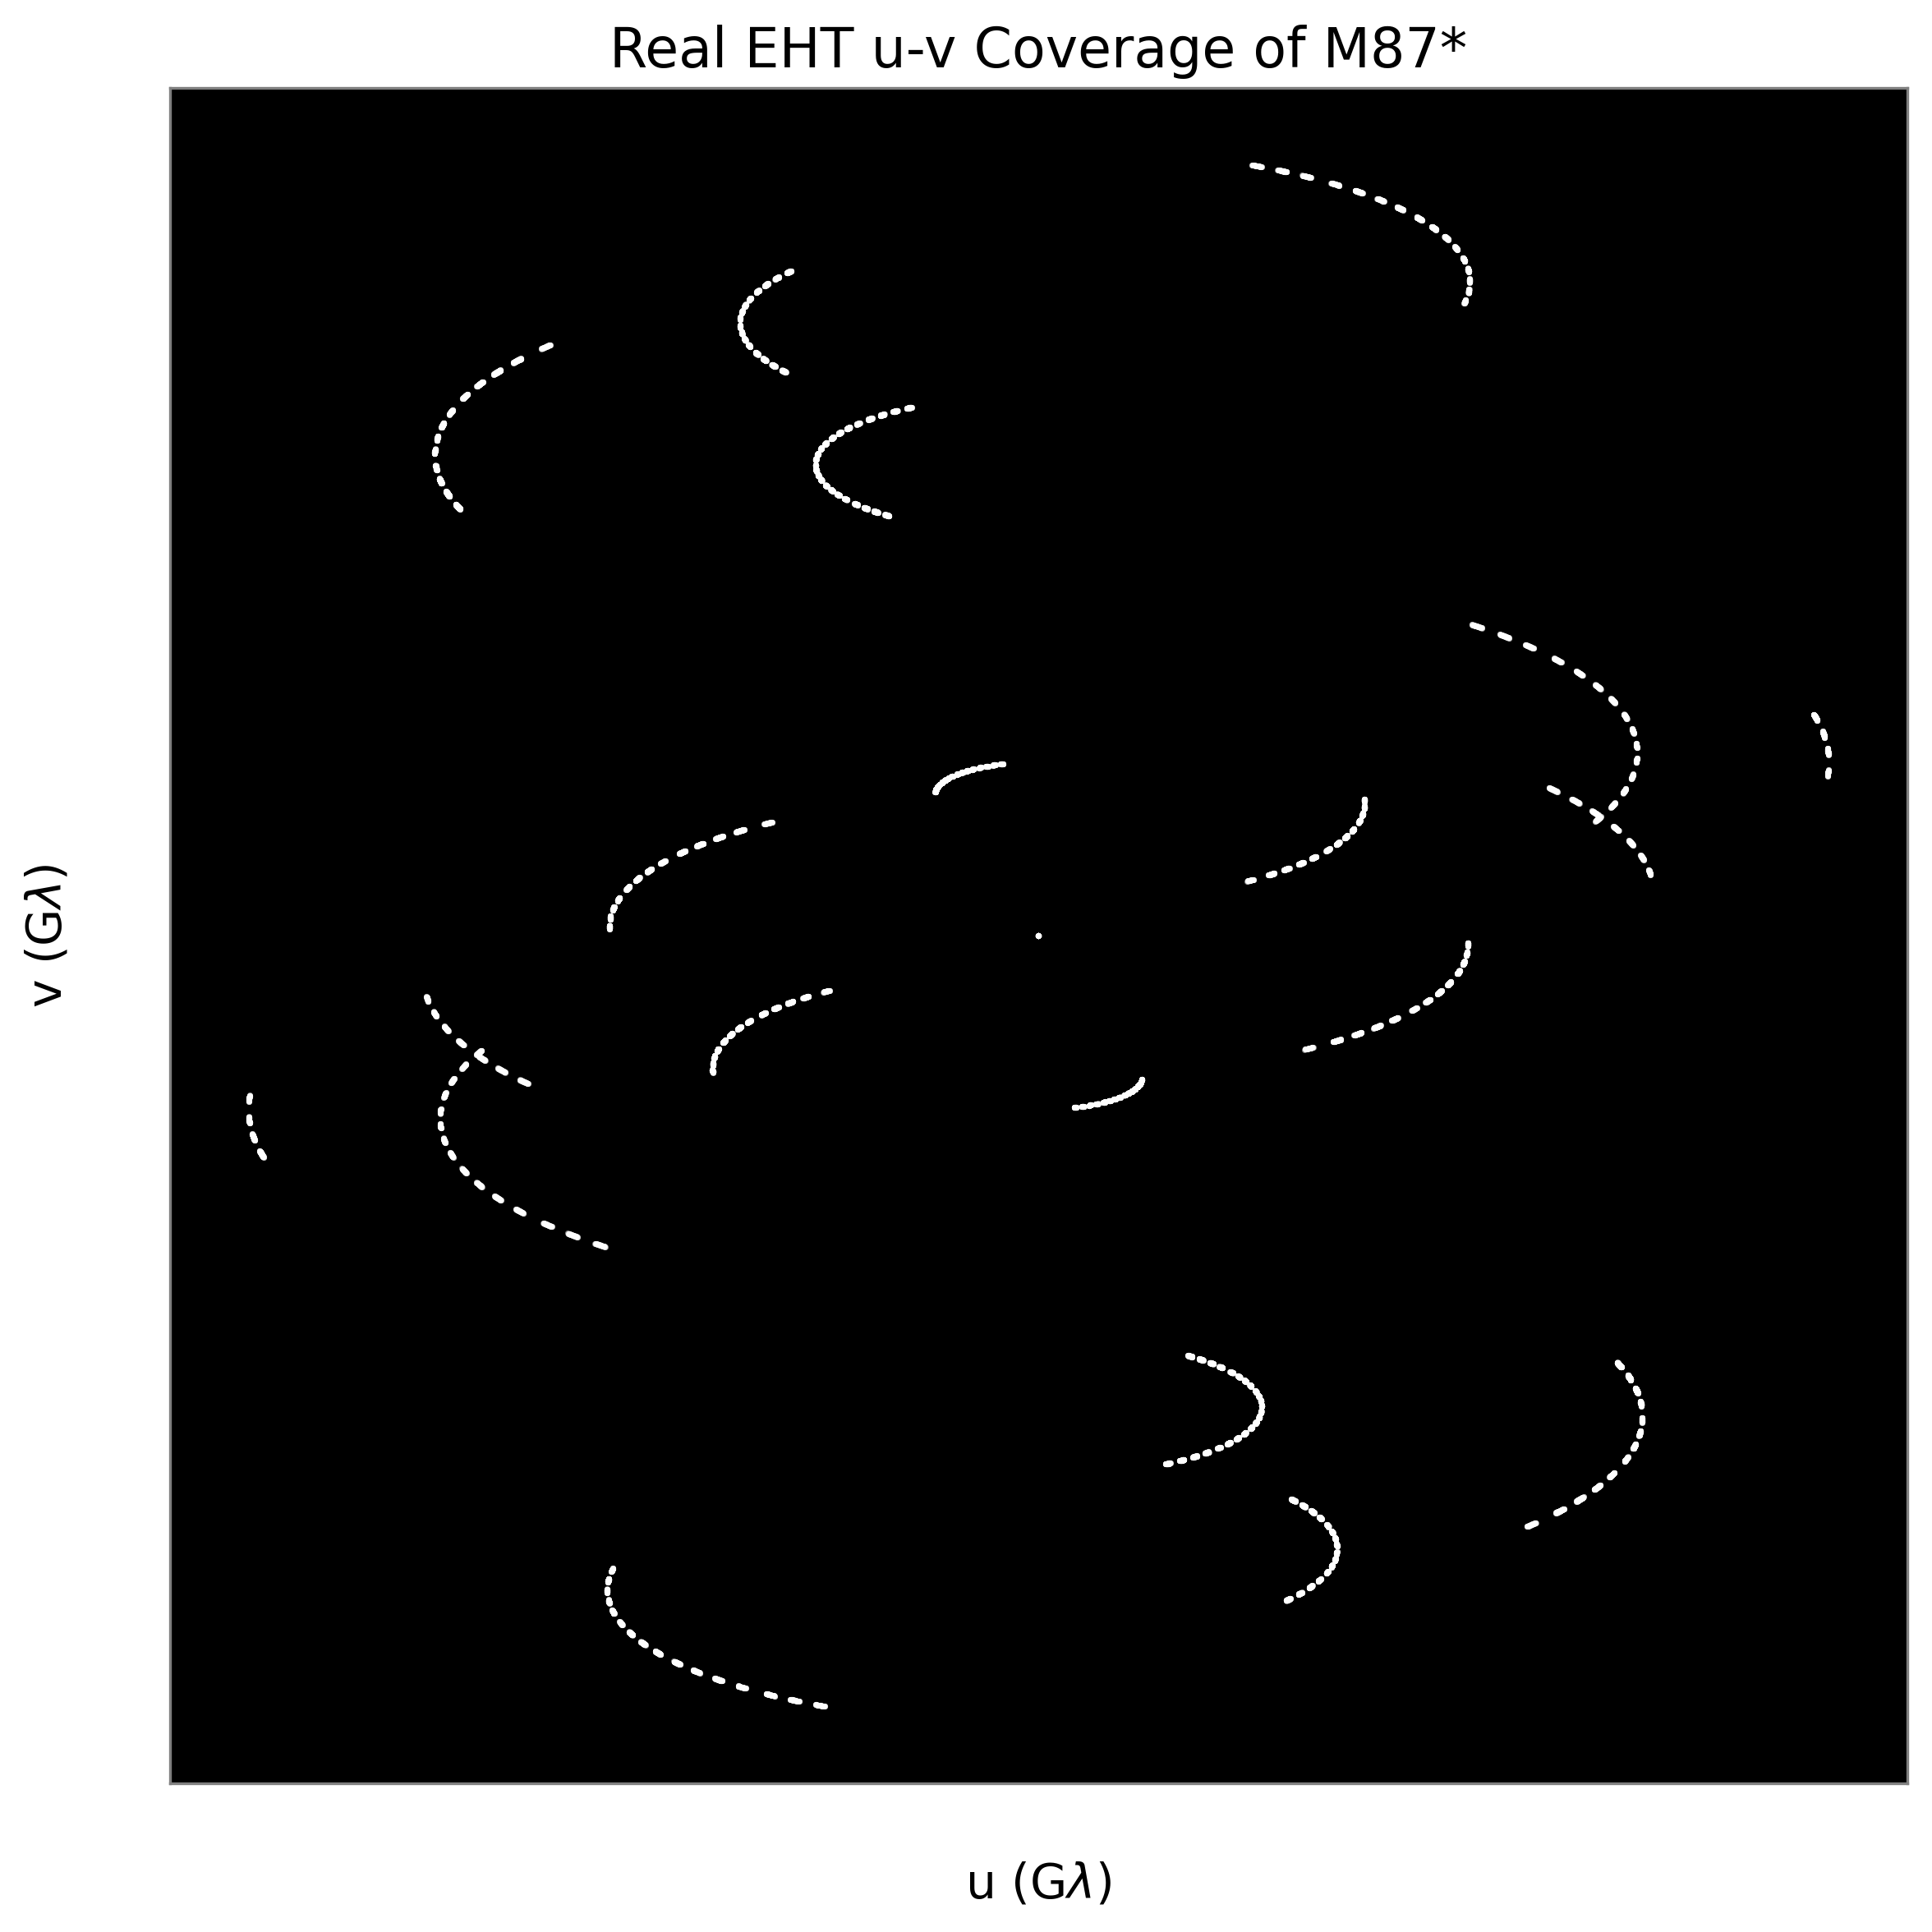

These are the actual (u,v) tracks from 8645 measurements.
Each point is one complex visibility measured by a pair of telescopes.
Compare this to the simulated coverage in Notebook 2!


In [63]:
# Extract u-v coordinates (in units of observing wavelength)
u_real = obs.data['u']
v_real = obs.data['v']

# Convert to Giga-lambda for cleaner axis labels
u_glam = u_real / 1e9
v_glam = v_real / 1e9

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_facecolor('black')
ax.scatter(u_glam, v_glam, c='white', s=0.5, alpha=0.5)
ax.scatter(-u_glam, -v_glam, c='white', s=0.5, alpha=0.5)  # conjugate points
ax.set_xlabel(r'u (G$\lambda$)', fontsize=14)
ax.set_ylabel(r'v (G$\lambda$)', fontsize=14)
ax.set_title('Real EHT u-v Coverage of M87*', fontsize=16)
ax.tick_params(labelsize=12, colors='white')
for spine in ax.spines.values():
    spine.set_color('gray')
plt.tight_layout()
plt.show()

print(f"These are the actual (u,v) tracks from {len(obs.data)} measurements.")
print(f"Each point is one complex visibility measured by a pair of telescopes.")
print(f"Compare this to the simulated coverage in Notebook 2!")

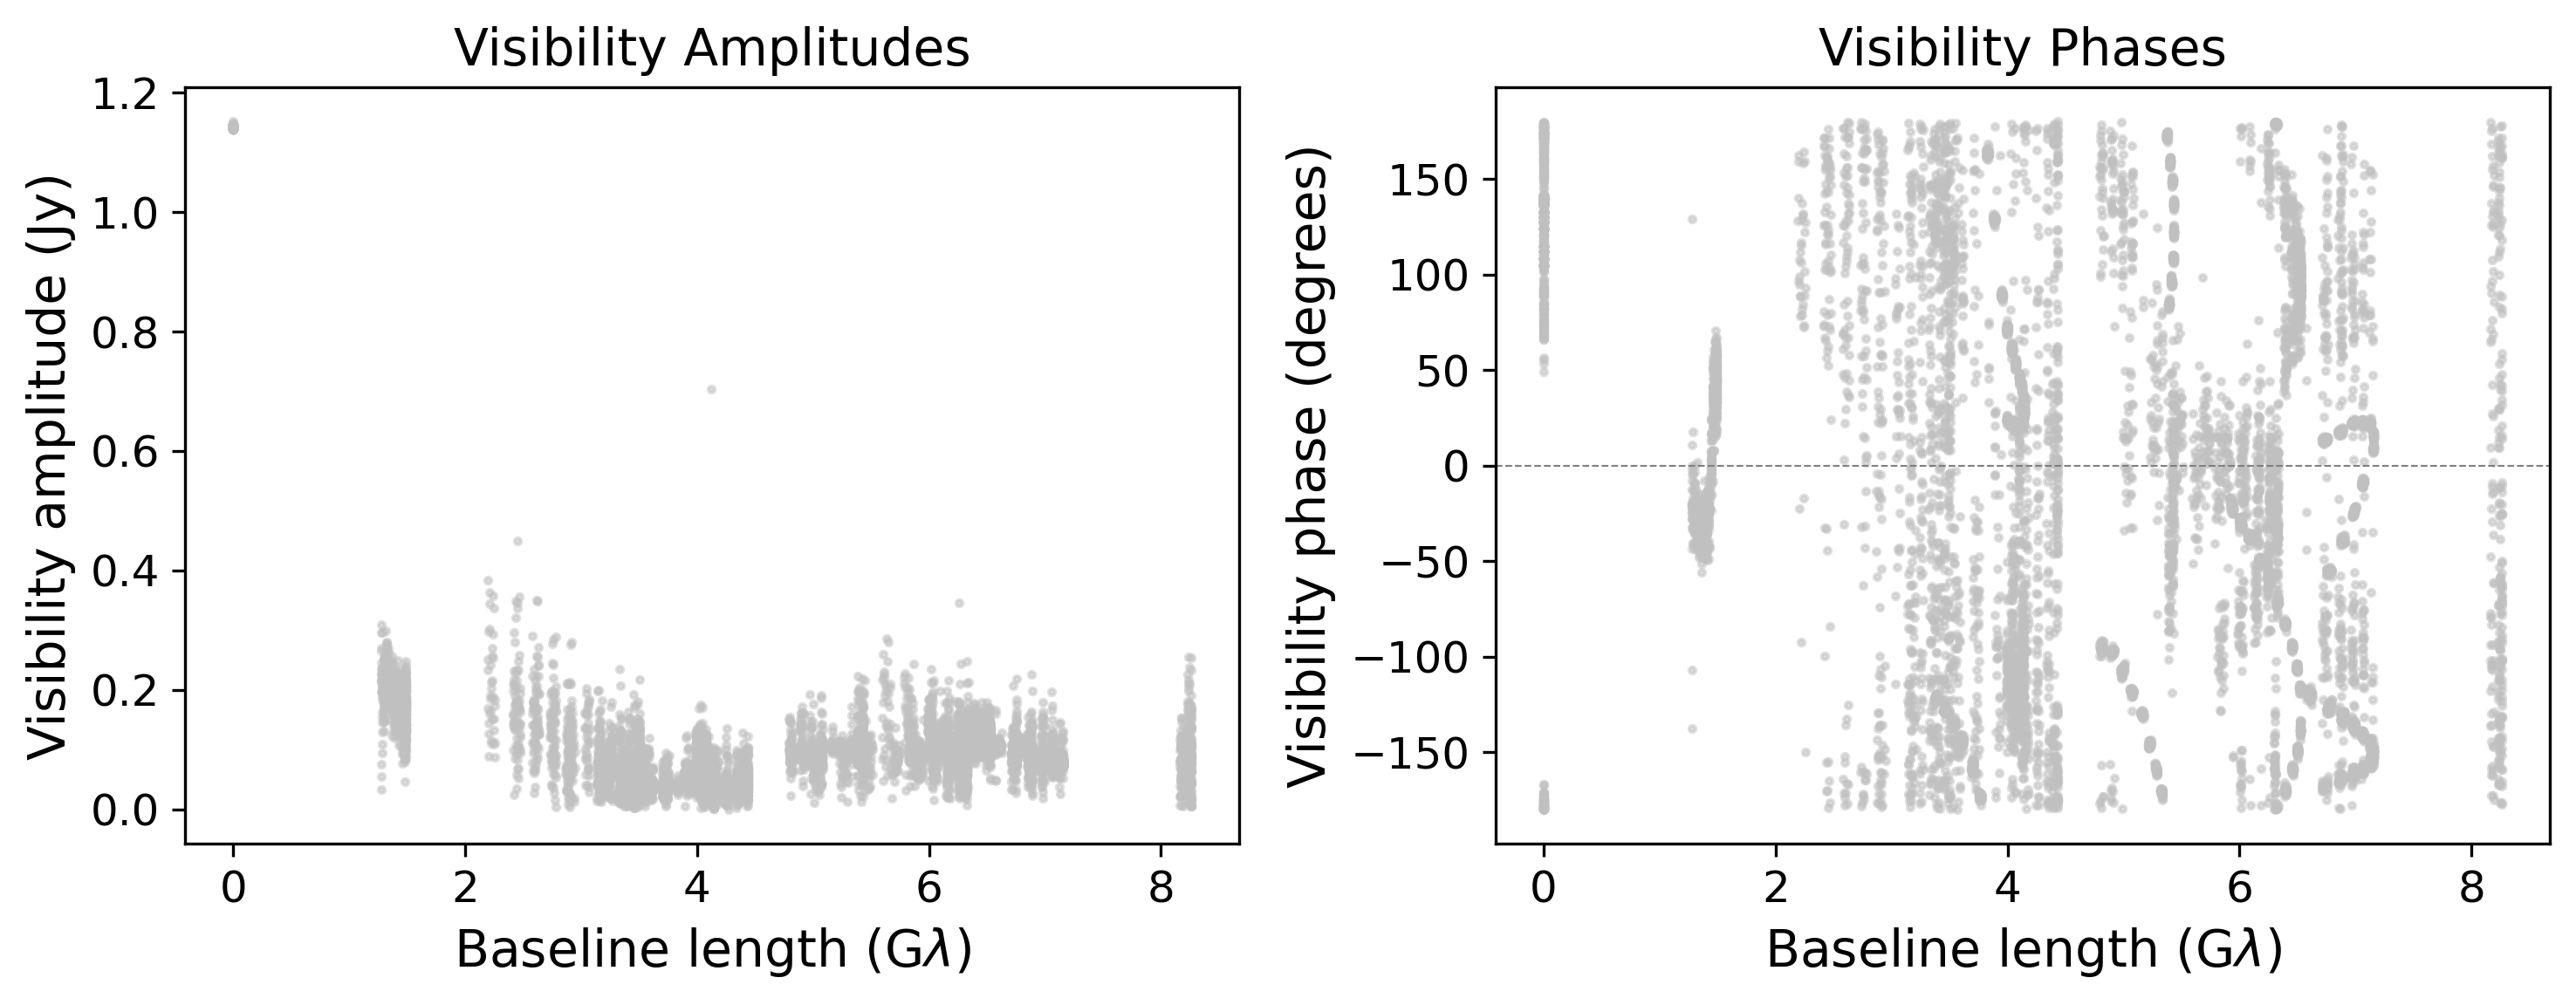

The dip in visibility amplitude around 3.4 Glambda is the signature of a RING!
A ring's Fourier transform has a null (minimum) whose location encodes the ring's diameter.

These are the actual measurements used to make the first image of M87*.


In [65]:
# Visibility amplitudes vs baseline length
# This is the "radial profile" of the Fourier transform

uvdist = np.sqrt(u_real**2 + v_real**2) / 1e9  # baseline length in Glambda
vis_amp = np.abs(obs.data['vis'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Visibility amplitude
axes[0].scatter(uvdist, vis_amp, c='silver', s=3, alpha=0.5)
axes[0].set_xlabel(r'Baseline length (G$\lambda$)', fontsize=14)
axes[0].set_ylabel('Visibility amplitude (Jy)', fontsize=14)
axes[0].set_title('Visibility Amplitudes', fontsize=14)
axes[0].tick_params(labelsize=12)

# Closure phases (robust observable, insensitive to station-based errors)
try:
    cphase = obs.cphase_arr(count='min')
    if len(cphase) > 0:
        axes[1].scatter(range(len(cphase)), cphase['cphase'],
                        c='silver', s=3, alpha=0.5)
        axes[1].set_xlabel('Closure phase index', fontsize=14)
        axes[1].set_ylabel('Closure phase (degrees)', fontsize=14)
        axes[1].set_title('Closure Phases', fontsize=14)
        axes[1].axhline(0, color='gray', lw=0.5, ls='--')
        axes[1].tick_params(labelsize=12)
except Exception:
    # Fallback: plot visibility phases instead
    vis_phase = np.angle(obs.data['vis'], deg=True)
    axes[1].scatter(uvdist, vis_phase, c='silver', s=3, alpha=0.5)
    axes[1].set_xlabel(r'Baseline length (G$\lambda$)', fontsize=14)
    axes[1].set_ylabel('Visibility phase (degrees)', fontsize=14)
    axes[1].set_title('Visibility Phases', fontsize=14)
    axes[1].axhline(0, color='gray', lw=0.5, ls='--')
    axes[1].tick_params(labelsize=12)

plt.tight_layout()
plt.show()

print("The dip in visibility amplitude around 3.4 Glambda is the signature of a RING!")
print("A ring's Fourier transform has a null (minimum) whose location encodes the ring's diameter.")
print("\nThese are the actual measurements used to make the first image of M87*.")

**What do you notice?** The visibility amplitudes drop to a minimum around $\sim 3.4\,\text{G}\lambda$. In Notebook 2, we saw that a ring in image space creates a null in its Fourier transform. The location of this null encodes the ring's diameter:

$$d \approx \frac{1}{u_{\text{null}}} \approx \frac{1}{3.4 \times 10^9\,\lambda} \approx 40\,\mu\text{as}$$

Even before making an image, the data itself tells us M87* has a ring-like structure about $40$ microarcseconds across!

## Step 3.3: Reconstructing with ehtim

We will use `eht-imaging`'s `Imager` class to reconstruct an image. To demonstrate the full pipeline reliably, we'll simulate observations of a GRMHD black hole model using the real EHT array, then reconstruct it.

Under the hood, ehtim does exactly what we built by hand in Notebook 2:

| Our Notebook 2 | eht-imaging |
|---|---|
| `jnp.fft.fft2` | Forward model (DFT/FFT) |
| $\chi^2$ + TV | `data_term` + `reg_term` |
| `jax.grad` | Analytic gradients + L-BFGS optimizer |
| Adam loop | `imgr.make_image_I()` |

Same recipe. Production-grade implementation.

In [66]:
# Load a GRMHD simulation model and the EHT array
im_model = eh.image.load_image('./data/models/avery_sgra_eofn.txt')
eht_array = eh.array.load_txt('./data/arrays/EHT2017.txt')

# Simulate an EHT observation of the model
obs_sim = im_model.observe(eht_array, tint=60, tadv=600, tstart=0, tstop=24, bw=4e9,
                           add_th_noise=True, jones=False, ttype='direct')
obs_sim = obs_sim.add_fractional_noise(0.02)

print(f"Model: {im_model.xdim}x{im_model.ydim}, flux = {im_model.total_flux():.2f} Jy")
print(f"Simulated observation: {len(obs_sim.data)} visibilities")
print(f"Array resolution: {obs_sim.res()*206265e6:.1f} microarcseconds")

Loading text image:  ./data/models/avery_sgra_eofn.txt
Generating empty observation file . . . 
Producing clean visibilities from image with direct FT . . . 
Adding gain + phase errors to data and applying a priori calibration . . . 
Adding thermal noise to data . . . 
Model: 100x100, flux = 2.49 Jy
Simulated observation: 1030 visibilities
Array resolution: 23.6 microarcseconds


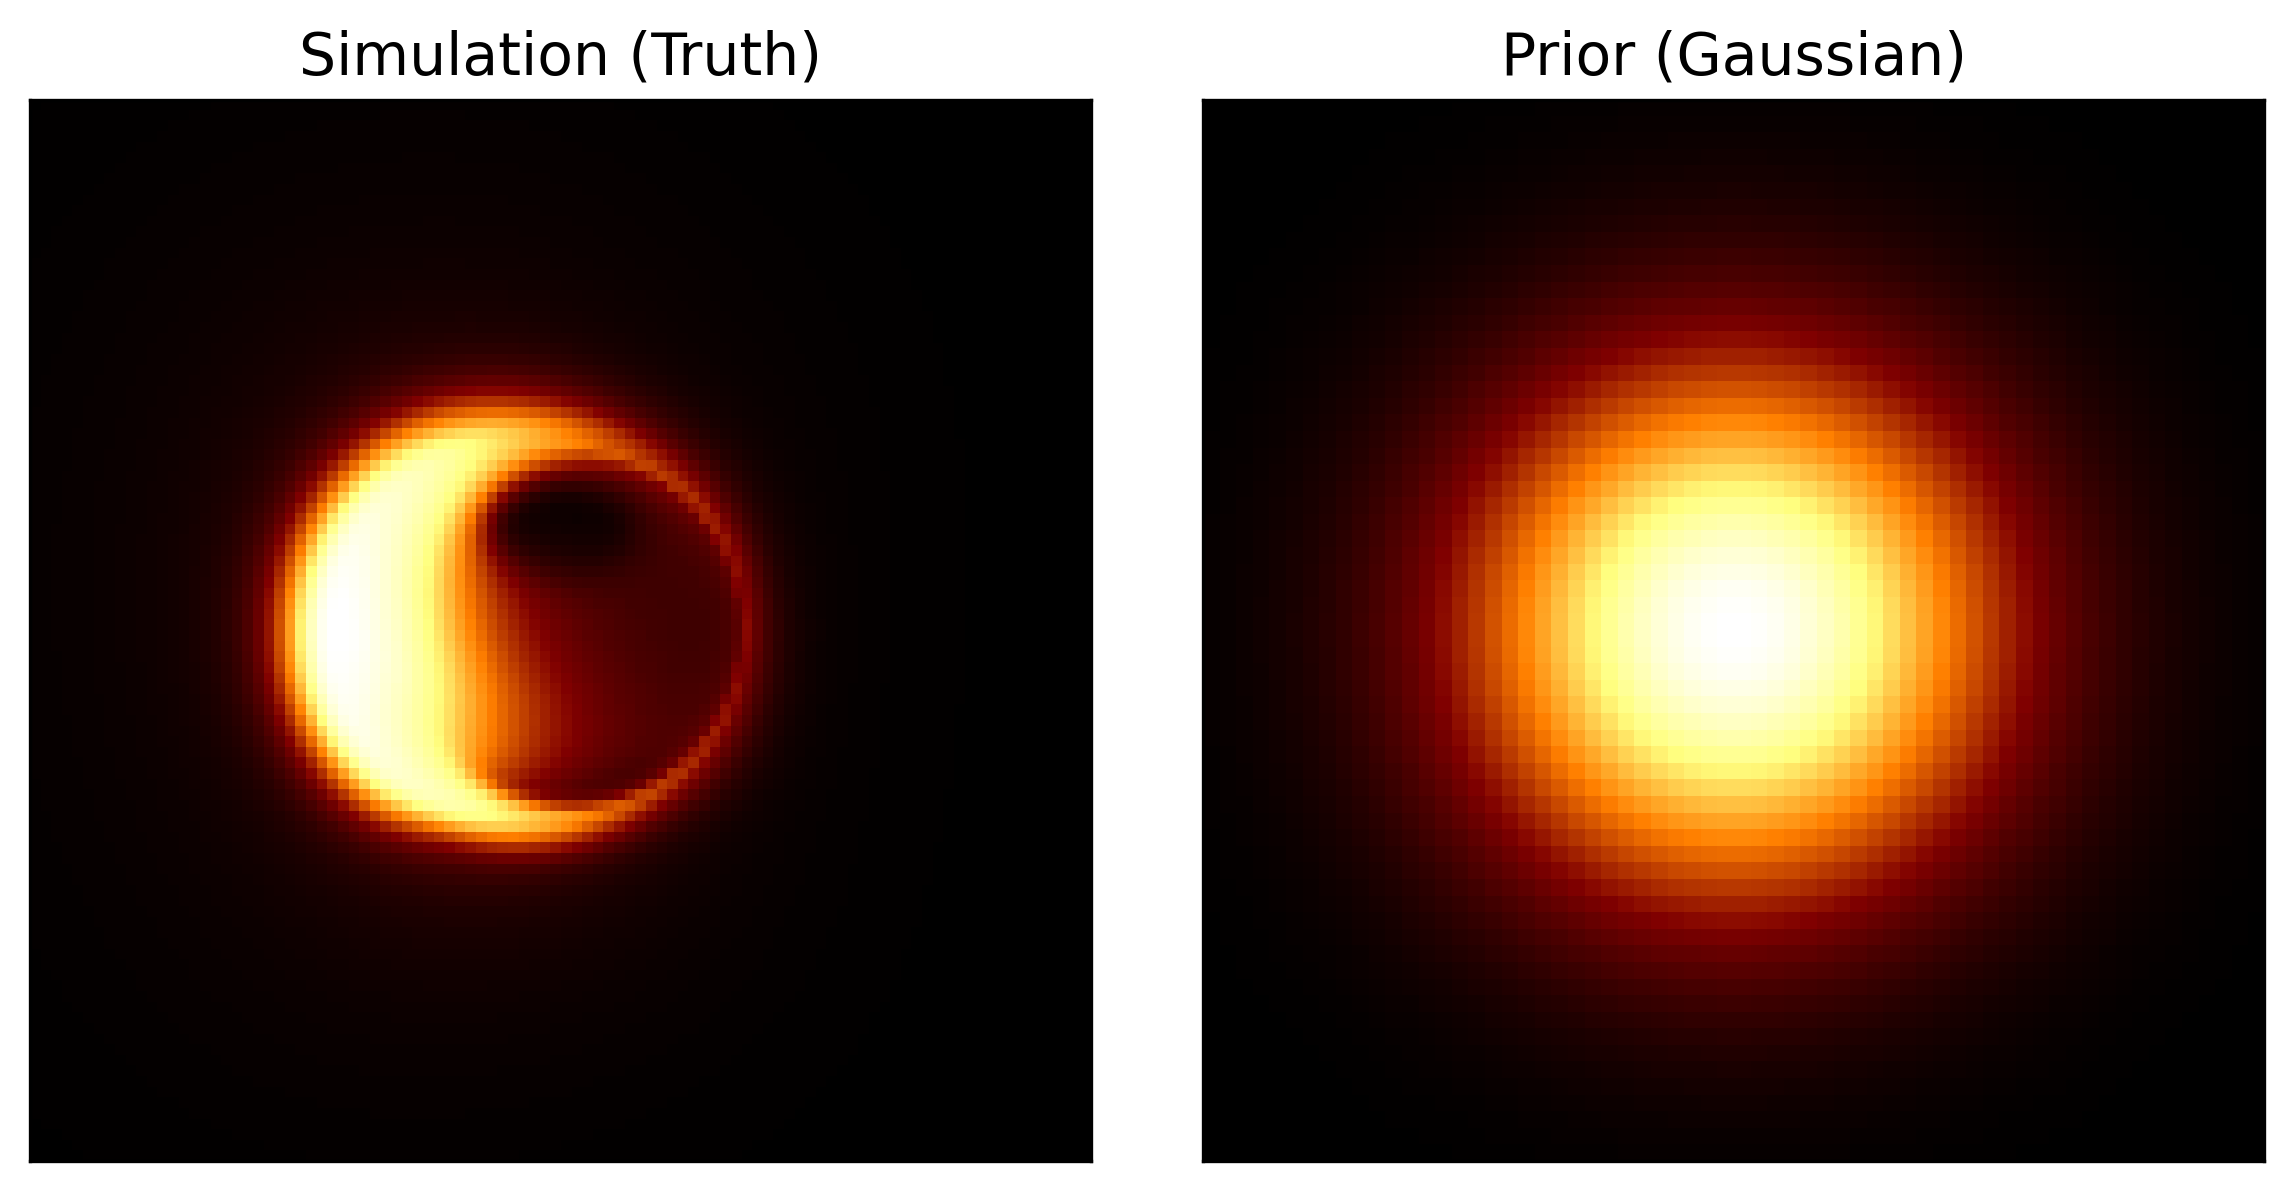

The prior is a symmetric Gaussian — no ring structure.
Any ring in the reconstruction must come from the DATA.


In [69]:
# Create the prior image — a Gaussian blob
zbl_sim = im_model.total_flux()
fov_sim = im_model.fovx()

prior_sim = eh.image.make_square(obs_sim, 64, fov_sim)
prior_sim = prior_sim.add_gauss(zbl_sim, (0.4*fov_sim, 0.4*fov_sim, 0, 0, 0))
res_sim = obs_sim.res()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(im_model.imarr(), cmap='afmhot', origin='lower')
axes[0].set_title('Simulation (Truth)', fontsize=14)
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[1].imshow(prior_sim.imarr(), cmap='afmhot', origin='lower')
axes[1].set_title('Prior (Gaussian)', fontsize=14)
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.tight_layout()
plt.show()

print("The prior is a symmetric Gaussian — no ring structure.")
print("Any ring in the reconstruction must come from the DATA.")

In [70]:
# Multi-round reconstruction
# Round 1: visibility-only with heavy regularization
print("Round 1: finding gross structure...")
imgr = eh.imager.Imager(obs_sim, prior_sim, prior_im=prior_sim, flux=zbl_sim,
    data_term={'vis': 1},
    reg_term={'simple': 1},
    maxit=200, ttype='fast')
imgr.make_image_I(show_updates=False)

# Converge (blur + re-image)
for i in range(3):
    imgr.init_next = imgr.out_last().blur_circ(res_sim)
    imgr.make_image_I(show_updates=False)
out1 = imgr.out_last()
print("Round 1 done.")

# Round 2: add closure phases, lighter regularization
print("Round 2: refining with closure phases...")
init2 = out1.blur_circ(res_sim)
imgr2 = eh.imager.Imager(obs_sim, init2, prior_im=prior_sim, flux=zbl_sim,
    data_term={'vis': 1, 'cphase': 1},
    reg_term={'simple': 0.1, 'tv': 0.01},
    maxit=200, ttype='fast')
imgr2.make_image_I(show_updates=False)
for i in range(3):
    imgr2.init_next = imgr2.out_last().blur_circ(res_sim)
    imgr2.make_image_I(show_updates=False)
out_final = imgr2.out_last()
print("Round 2 done — reconstruction complete!")

Round 1: finding gross structure...
Initializing imager data products . . .
Imager run 1 
Imaging . . .
time: 5.858899 s
J: 0.232235
chi2_vis : 0.38 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Imager run 2 
Imaging . . .
time: 5.949641 s
J: 0.210898
chi2_vis : 0.36 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Imager run 3 
Imaging . . .
time: 5.956252 s
J: 0.211674
chi2_vis : 0.36 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Imager run 4 
Imaging . . .
time: 6.284671 s
J: 0.212412
chi2_vis : 0.36 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Round 1 done.
Round 2: refining with closure phases...
Initializing imager data products . . .
Imager run 1 
Imaging . . .
time: 15.219752 s
J: -1.288870
chi2_cphase : 0.29 chi2_vis : 0.32 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Imager run 2 
Imaging . . .
time: 15.157281 s
J: -1.287607
chi2_cphase : 0.28 chi2_vis : 0.32 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Imager run 3 
Imaging . . .
time: 15.005174 s
J: -1.285411
chi2_cphase : 0.28 c

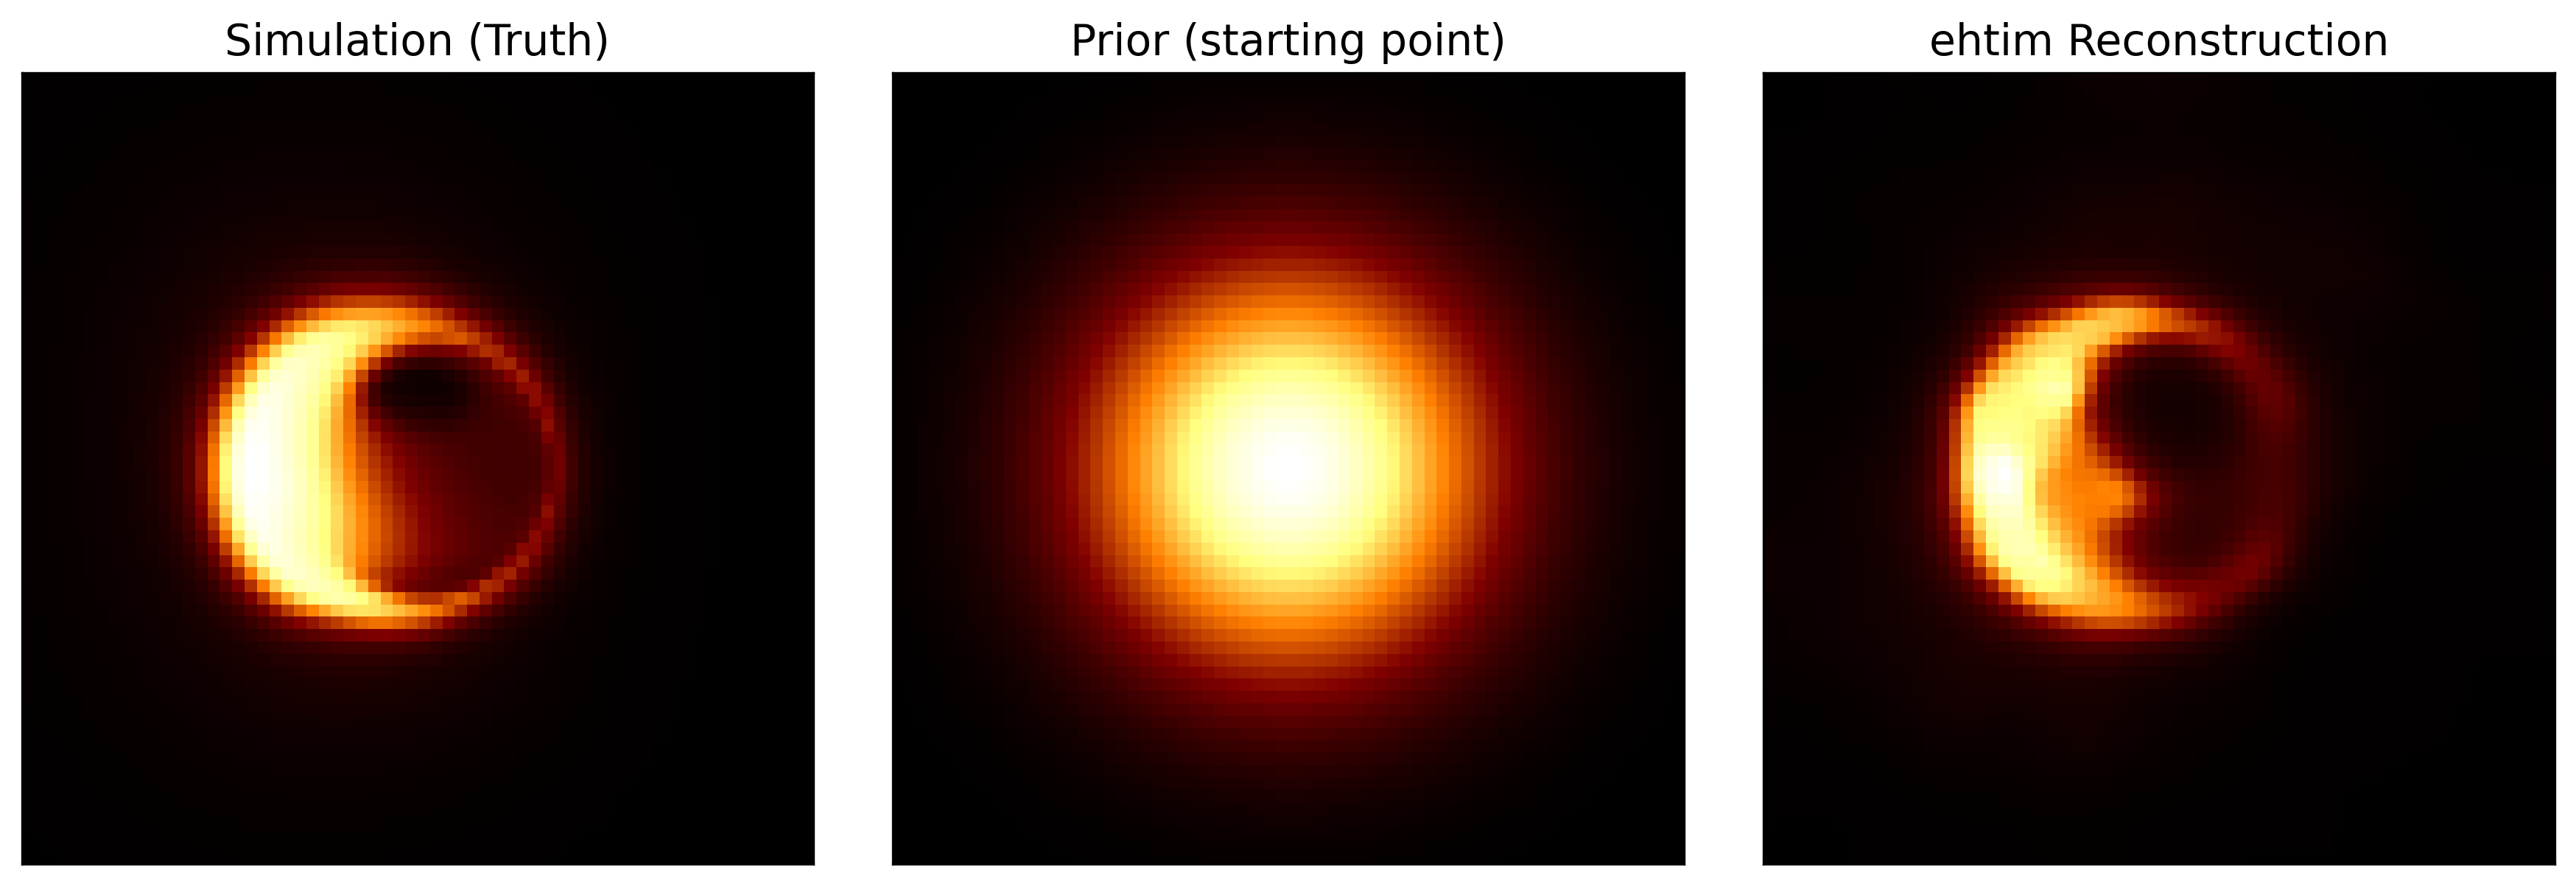

The crescent ring structure — including the brightness asymmetry —
is recovered from the simulated sparse Fourier data.
This is exactly the approach used by the EHT collaboration.


In [71]:
# Display: Truth | Prior | Reconstruction
recon_arr = out_final.imarr()
truth_arr = im_model.regrid_image(fov_sim, 64).imarr()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(truth_arr, cmap='afmhot', origin='lower')
axes[0].set_title('Simulation (Truth)', fontsize=14)
axes[1].imshow(prior_sim.imarr(), cmap='afmhot', origin='lower')
axes[1].set_title('Prior (starting point)', fontsize=14)
axes[2].imshow(recon_arr, cmap='afmhot', origin='lower')
axes[2].set_title('ehtim Reconstruction', fontsize=14)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

print("The crescent ring structure — including the brightness asymmetry —")
print("is recovered from the simulated sparse Fourier data.")
print("This is exactly the approach used by the EHT collaboration.")

## Step 3.4: Real M87* The Full Imaging Pipeline

Now let's reconstruct the **real M87\*** black hole using the full calibration pipeline from [EHT Paper IV](https://github.com/eventhorizontelescope/2019-D01-02):

In [72]:
# === Full EHT Pipeline (adapted from 2019-D01-02/eht-imaging) ===

# Pipeline parameters from EHT Paper IV
zbl_m87 = 0.60
prior_fwhm_m87 = 40.0 * eh.RADPERUAS
npix_m87 = 64
fov_m87 = 128 * eh.RADPERUAS
maxit_m87 = 100
ttype_m87 = 'direct'
uv_zblcut = 0.1e9

reg_term_m87 = {'simple': 100, 'tv': 1.0, 'tv2': 1.0, 'l1': 0.0, 'flux': 1e4}
data_term_m87 = {'amp': 0.2, 'cphase': 1.0, 'logcamp': 1.0}

# Station-specific SEFD error budgets (from EHT Paper III)
SEFD_error_budget = {'AA':0.10, 'AP':0.11, 'AZ':0.07, 'LM':0.22,
                     'PV':0.10, 'SM':0.15, 'JC':0.14, 'SP':0.07}
systematic_noise_m87 = {k: ((1+v)**0.5 - 1) * 0.25 for k,v in SEFD_error_budget.items()}
systematic_noise_m87['LM'] += 0.15  # extra noise for LMT variability

# Load and prepare data
obs_m87 = eh.obsdata.load_uvfits('./data/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits')
obs_m87.add_scans()
obs_m87 = obs_m87.avg_coherent(0., scan_avg=True)

# Rescale zero-baselines to separate compact from extended flux
zbl_tot = np.median(obs_m87.unpack_bl('AA','AP','amp')['amp'])
print(f"Total flux (AA-AP): {zbl_tot:.3f} Jy, compact flux: {zbl_m87:.3f} Jy")
multiplier = zbl_m87 / zbl_tot
for j in range(len(obs_m87.data)):
    if (obs_m87.data['u'][j]**2 + obs_m87.data['v'][j]**2)**0.5 >= uv_zblcut:
        continue
    for field in ['vis', 'sigma']:
        obs_m87.data[field][j] *= multiplier

obs_m87.reorder_tarr_snr()
obs_sc_m87 = obs_m87.copy()
res_m87 = obs_m87.res()

# Gaussian prior
gaussprior_m87 = eh.image.make_square(obs_sc_m87, npix_m87, fov_m87)
gaussprior_m87 = gaussprior_m87.add_gauss(zbl_m87, (prior_fwhm_m87, prior_fwhm_m87, 0, 0, 0))
gaussprior_m87 = gaussprior_m87.add_gauss(zbl_m87*1e-3, (prior_fwhm_m87, prior_fwhm_m87, 0, prior_fwhm_m87, prior_fwhm_m87))

# Reverse taper + systematic noise
obs_sc_m87 = obs_sc_m87.reverse_taper(5.0*eh.RADPERUAS)
obs_sc_m87 = obs_sc_m87.add_fractional_noise(0.02)
obs_sc_init_m87 = obs_sc_m87.copy()

# Pre-calibrate LMT to a Gaussian model
print("Pre-calibrating LMT...")
obs_LMT = obs_sc_init_m87.flag_uvdist(uv_max=2e9)
gaussLMT = eh.image.make_square(obs_m87, npix_m87, fov_m87)
gaussLMT = gaussLMT.add_gauss(0.6, (60*eh.RADPERUAS, 60*eh.RADPERUAS, 0, 0, 0))
caltab = eh.selfcal(obs_LMT, gaussLMT, sites=['LM'], gain_tol=1.0,
                    method='both', ttype=ttype_m87, caltable=True)
obs_sc_m87 = caltab.applycal(obs_sc_m87, interp='nearest', extrapolate=True)

def converge_pipeline(imgr, major=3):
    for _ in range(major):
        imgr.init_next = imgr.out_last().blur_circ(res_m87)
        imgr.make_image_I(show_updates=False)

# Round 1: amp + closure
print("Round 1: imaging with amplitudes + closures...")
imgr_m87 = eh.imager.Imager(obs_sc_m87, gaussprior_m87, prior_im=gaussprior_m87,
    flux=zbl_m87, data_term=data_term_m87, maxit=maxit_m87, norm_reg=True,
    systematic_noise=systematic_noise_m87, reg_term=reg_term_m87,
    ttype=ttype_m87, cp_uv_min=uv_zblcut)
imgr_m87.make_image_I(show_updates=False)
converge_pipeline(imgr_m87)

# Phase self-cal
obs_sc_m87 = eh.selfcal(obs_sc_m87, imgr_m87.out_last(), method='phase',
                         ttype=ttype_m87, solution_interval=0.0)

# Round 2: vis + closure (higher weights)
print("Round 2: imaging with visibilities + closures...")
init_m87 = imgr_m87.out_last().blur_circ(res_m87)
data_term2_m87 = {'vis': 2.0, 'cphase': 10.0, 'logcamp': 10.0}
imgr_m87 = eh.imager.Imager(obs_sc_m87, init_m87, prior_im=gaussprior_m87,
    flux=zbl_m87, data_term=data_term2_m87, maxit=maxit_m87, norm_reg=True,
    systematic_noise=systematic_noise_m87, reg_term=reg_term_m87,
    ttype=ttype_m87, cp_uv_min=uv_zblcut)
imgr_m87.make_image_I(show_updates=False)
converge_pipeline(imgr_m87)

# Full self-cal from scratch (phase all + amplitude LMT)
obs_sc_m87 = eh.selfcal(obs_sc_init_m87, imgr_m87.out_last(), method='phase', ttype=ttype_m87)
caltab = eh.selfcal(obs_sc_m87, imgr_m87.out_last(), sites=['LM'], method='both',
                    gain_tol=[0.02,0.2], ttype=ttype_m87, caltable=True)
obs_sc_m87 = caltab.applycal(obs_sc_m87, interp='nearest', extrapolate=True)

# Rounds 3+4: final refinement
print("Rounds 3+4: final refinement with self-cal...")
data_term3_m87 = {'vis': 10.0, 'cphase': 20.0, 'logcamp': 20.0}
for rnd in range(2):
    init_m87 = imgr_m87.out_last().blur_circ(res_m87)
    imgr_m87 = eh.imager.Imager(obs_sc_m87, init_m87, prior_im=gaussprior_m87,
        flux=zbl_m87, data_term=data_term3_m87, maxit=maxit_m87, norm_reg=True,
        systematic_noise=0.01, reg_term=reg_term_m87,
        ttype=ttype_m87, cp_uv_min=uv_zblcut)
    imgr_m87.make_image_I(show_updates=False)
    converge_pipeline(imgr_m87)

out_m87 = imgr_m87.out_last()
print("Reconstruction complete!")

Loading uvfits:  ./data/SR1_M87_2017_096_lo_hops_netcal_StokesI.uvfits
no IF in uvfits header!
POLREP_UVFITS: circ
Number of uvfits Correlation Products: 4
No NX table in uvfits!
Total flux (AA-AP): 1.140 Jy, compact flux: 0.600 Jy
Pre-calibrating LMT...
U-V flagged 226/274 visibilities
Computing the Model Visibilities with direct Fourier Transform...
Producing clean visibilities from image with direct FT . . . 
Not Using Multiprocessing
Scan 22/23 : [----------------------------  ]95%
self_cal time: 0.268467 s
No Calibration  Data for SR !
No Calibration  Data for PV !
Round 1: imaging with amplitudes + closures...
Initializing imager data products . . .
U-V flagged 32/274 visibilities
U-V flagged 242/274 visibilities
Imager run 1 
Imaging . . .
time: 15.383984 s
J: 21.144773
chi2_amp : 18.00 chi2_cphase : 1.67 chi2_logcamp : 2.93 
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
Imager run 2 
Imaging . . .
time: 14.924006 s
J: 21.246352
chi2_amp : 17.96 chi2_cphase : 1.56 chi2_logcamp : 2

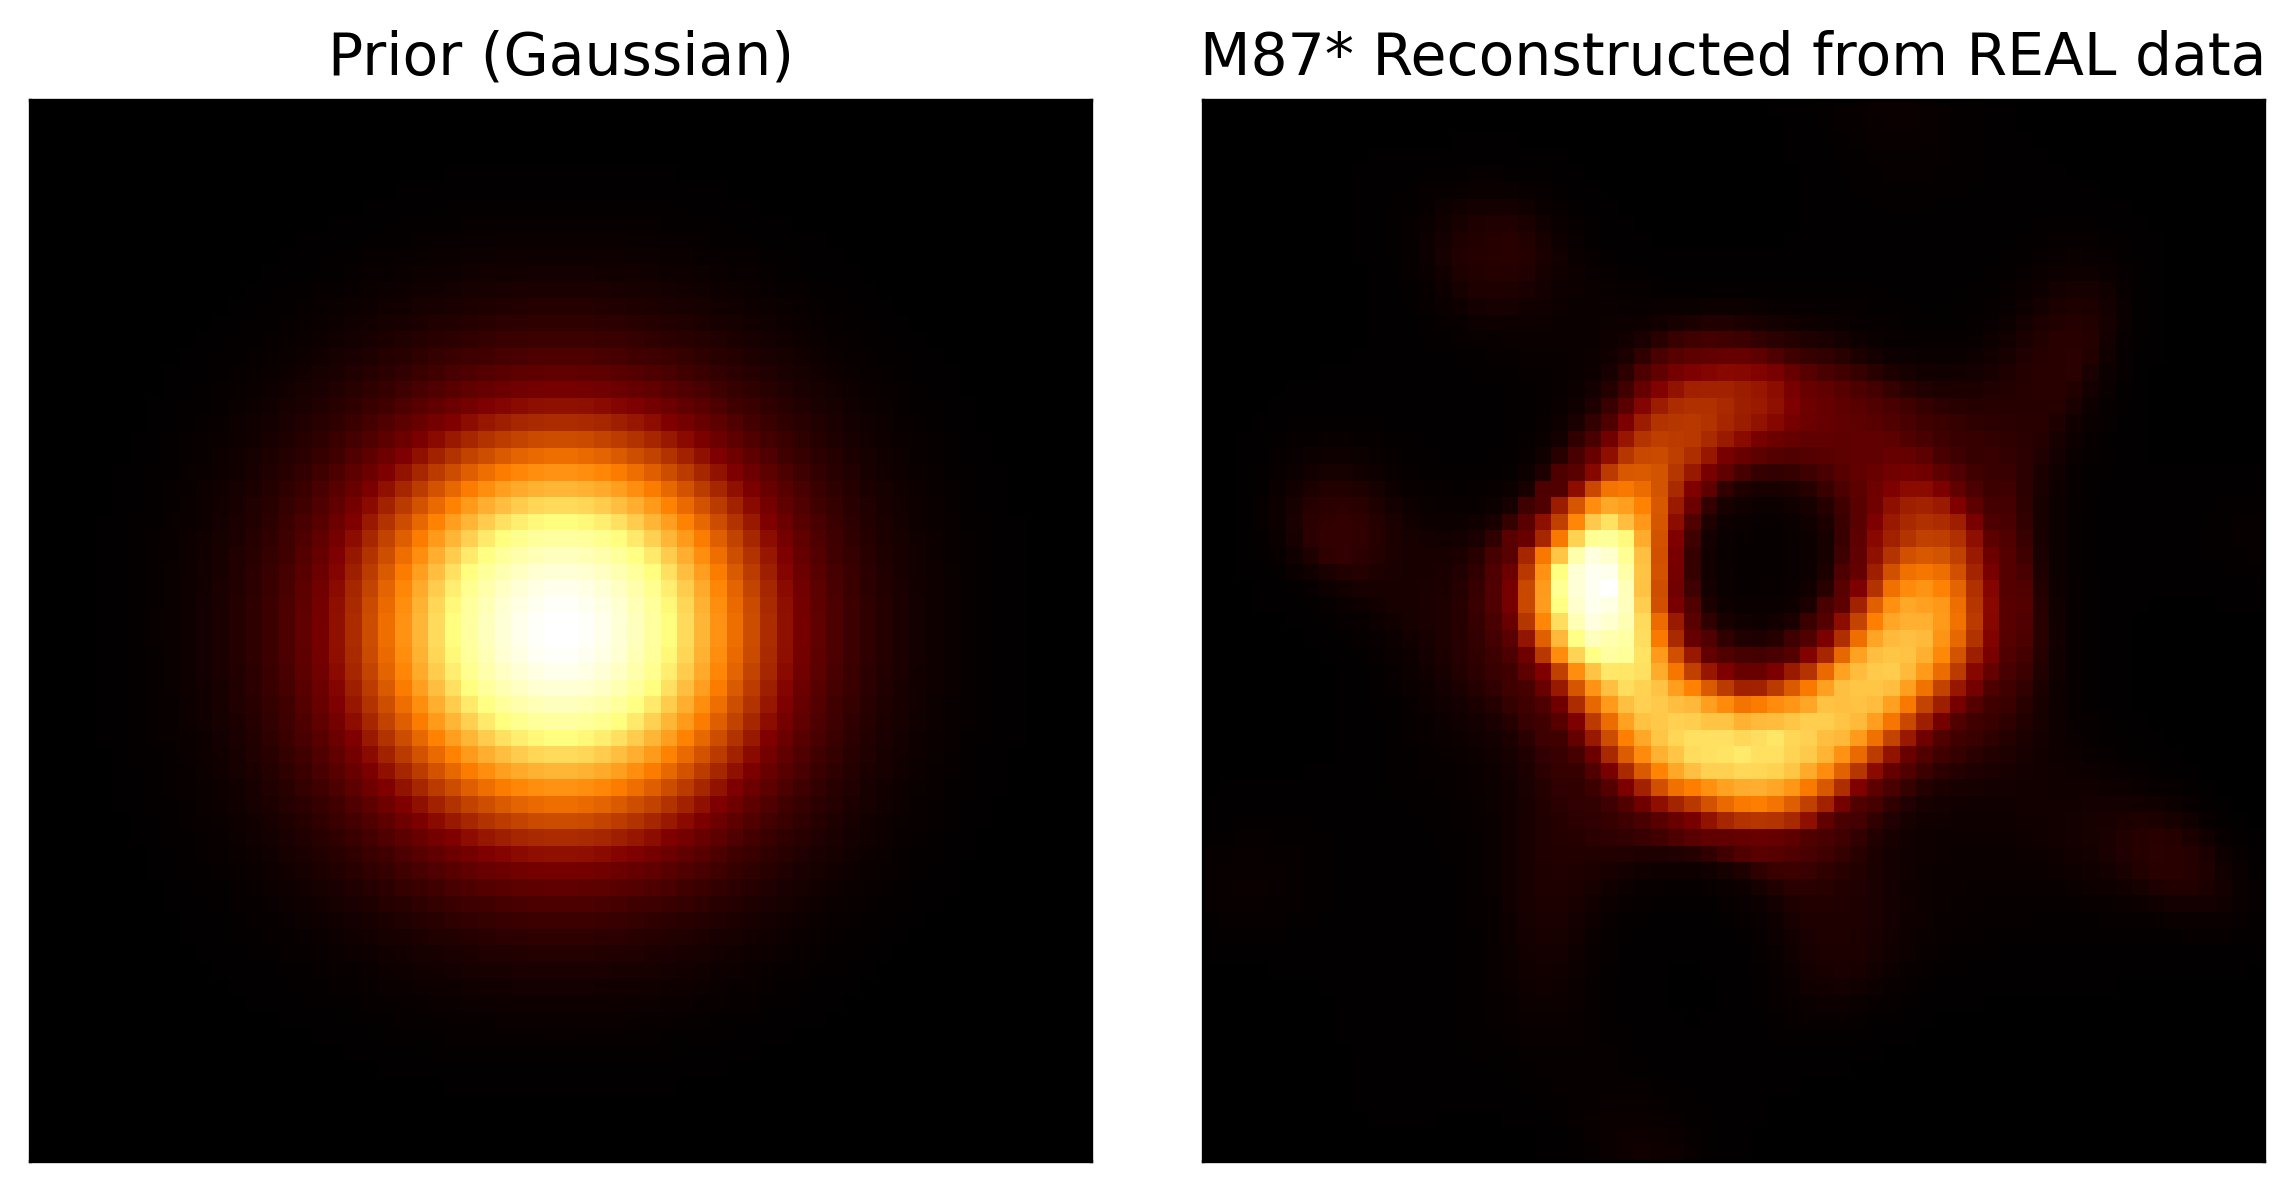

Right: M87* reconstructed from REAL EHT data using the full pipeline!
The crescent ring with brighter emission in the south is clearly visible.
This is the same approach that produced the historic first image of a black hole.


In [73]:
# Display the M87* reconstruction
m87_arr = out_m87.imarr()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(gaussprior_m87.imarr(), cmap='afmhot', origin='lower',
               extent=[-64, 64, -64, 64])
axes[0].set_title('Prior (Gaussian)', fontsize=14)

axes[1].imshow(m87_arr, cmap='afmhot',
               extent=[-64, 64, -64, 64])
axes[1].set_title('M87* Reconstructed from REAL data', fontsize=14)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print("Right: M87* reconstructed from REAL EHT data using the full pipeline!")
print("The crescent ring with brighter emission in the south is clearly visible.")
print("This is the same approach that produced the historic first image of a black hole.")